# INF6422E – Advanced Concepts in Computer Security  
## Final project – Winter 2026  

### Comparing supervised vs unsupervised models for detecting known and zero-day attacks


--- 
  
## Students  
- Antoine Khoueiry – *Matricule:* 2487137  
- Louis Junior Mpandzo-Otiankouya – *Matricule:* 2421549  

---

## Objective

...

---

## Dataset

This study uses the **CICIDS2017** dataset, combining:
- **Monday traffic** (Benign baseline used to learn normal network behavior)
- **Tuesday traffic** (Benign + Brute Force attacks used as known attack data for supervised training)
- **Thursday traffic** (Benign + Web Attacks used as a **zero-day dataset**, not seen during training)

---

## Notebook Structure

1. ...
2. ...


# 1. Dataset Analysis and Preprocessing

### Dataset Construction (Monday + Tuesday + Thursday – Zero-Day Setup)

- **Monday-WorkingHours.pcap_ISCX**: contains only benign (normal) traffic and is used to train the models on normal network behavior.

-  **Tuesday-WorkingHours.pcap_ISCX**: contains benign traffic mixed with brute-force attacks and is used to train the supervised model on known attack types.

-  **Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX**: contains web-based attacks and is used exclusively as a zero-day dataset. These attacks are not included during training, allowing evaluation of the models’ ability to detect previously unseen threats.

The following steps load the selected CSV files and construct separate datasets for training and zero-day testing.


In [1]:
import pandas as pd
import numpy as np

# File paths
monday_path = "Monday-WorkingHours.pcap_ISCX.csv"
tuesday_path = "Tuesday-WorkingHours.pcap_ISCX.csv"
thursday_path = "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"

# Load datasets
df_monday = pd.read_csv(monday_path)
df_tuesday = pd.read_csv(tuesday_path)
df_thursday = pd.read_csv(thursday_path)

print("Monday:", df_monday.shape)
print("Tuesday:", df_tuesday.shape)
print("Thursday:", df_thursday.shape)

# Training dataset (Known behavior)
df_train = pd.concat(
    [df_monday, df_tuesday],
    axis=0,
    ignore_index=True
)

# Zero-day dataset
df_zero_day = df_thursday.copy()

print("Training dataset:", df_train.shape)
print("Zero-day dataset:", df_zero_day.shape)



Monday: (529918, 79)
Tuesday: (445909, 79)
Thursday: (170366, 79)
Training dataset: (975827, 79)
Zero-day dataset: (170366, 79)


### Cleaning Both Datasets

In [ ]:
for df in [df_train, df_zero_day]:

    # Clean column names
    df.columns = df.columns.str.strip()

    # Replace infinite values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Drop missing values
    df.dropna(inplace=True)

    # Create Binary Label
    df["BinaryLabel"] = df["Label"].apply(
        lambda x: "Benign" if x == "BENIGN" else "Attack"
    )

print("Cleaning done")

Cleaning done


### Splitting Features and Labels

In [ ]:
# Supervised training data
X_train = df_train.drop(columns=["Label", "BinaryLabel"])
y_train = df_train["BinaryLabel"]

# Zero-day data
X_zero = df_zero_day.drop(columns=["Label", "BinaryLabel"])
y_zero = df_zero_day["BinaryLabel"]

print("Training features:", X_train.shape)
print("Zero-day features:", X_zero.shape)

Training features: (975126, 78)
Zero-day features: (170231, 78)


### Standardization


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_zero_scaled = scaler.transform(X_zero)

print("Scaling complete")

Scaling complete


### Encoding labels

In [11]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Encode labels
y_train_encoded = label_encoder.fit_transform(y_train)
y_zero_encoded = label_encoder.transform(y_zero)

print("Labels encoded successfully")

Labels encoded successfully


## Model Training

## Supervised learning

### Test Split

In [12]:
from sklearn.model_selection import train_test_split

# Split known data into train and known-test
X_train_final, X_known_test, y_train_final, y_known_test = train_test_split(
    X_train_scaled,
    y_train_encoded,
    test_size=0.2,
    stratify=y_train_encoded,
    random_state=42
)

print("Training samples:", X_train_final.shape[0])
print("Known test samples:", X_known_test.shape[0])

Training samples: 780100
Known test samples: 195026


#### Training Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_final, y_train_final)

print("Random Forest trained successfully")

Random Forest trained successfully


### Evaluating Known attack predictions

In [14]:
from sklearn.metrics import classification_report

# Known attack predictions
y_known_pred = rf_model.predict(X_known_test)

print("=== Known Attack Results ===")
print(classification_report(y_known_test, y_known_pred))

=== Known Attack Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2766
           1       1.00      1.00      1.00    192260

    accuracy                           1.00    195026
   macro avg       1.00      1.00      1.00    195026
weighted avg       1.00      1.00      1.00    195026



### Evaluating Zero-Day Attacks

In [15]:
# Zero-day predictions
y_zero_pred = rf_model.predict(X_zero_scaled)

print("=== Zero-Day Results ===")
print(classification_report(y_zero_encoded, y_zero_pred))

=== Zero-Day Results ===
              precision    recall  f1-score   support

           0       1.00      0.00      0.00      2180
           1       0.99      1.00      0.99    168051

    accuracy                           0.99    170231
   macro avg       0.99      0.50      0.50    170231
weighted avg       0.99      0.99      0.98    170231



The Random Forest classifier achieved near-perfect performance on known attacks, with an accuracy of 100%. However, when evaluated on zero-day attacks, the model failed to detect previously unseen attack patterns, achieving a recall of 0.00 for the attack class. This result highlights the limitation of supervised learning models in detecting novel attacks that were not present during training.

## Confusion Matrix

### Known Attack Confusion Matrix

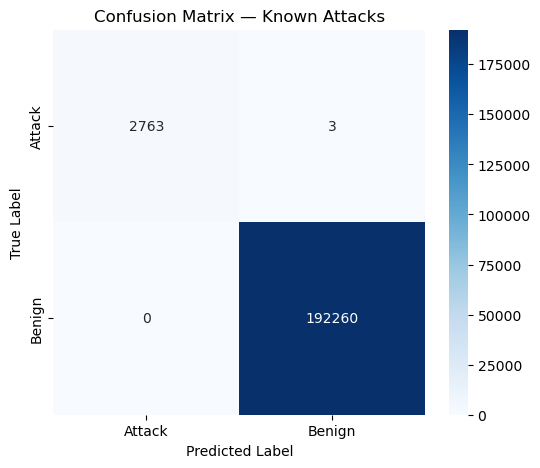

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Known attack confusion matrix
cm_known = confusion_matrix(y_known_test, y_known_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_known,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title("Confusion Matrix — Known Attacks")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

### Known Attack Confusion Matrix

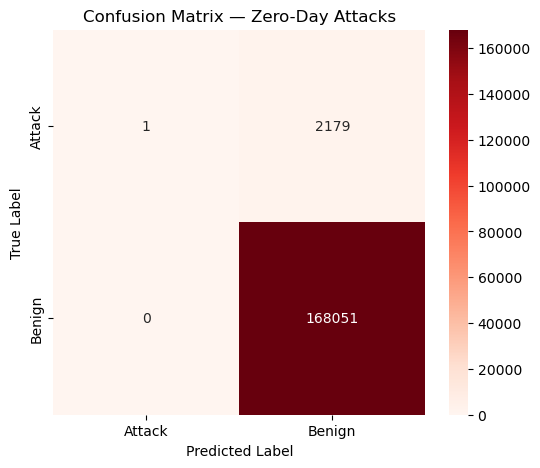

In [19]:
# Zero-day confusion matrix
cm_zero = confusion_matrix(y_zero_encoded, y_zero_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_zero,
            annot=True,
            fmt='d',
            cmap='Reds',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title("Confusion Matrix — Zero-Day Attacks")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

The confusion matrix for zero-day attacks shows that only 1 out of 2180 attack samples was correctly detected, while 2179 were misclassified as benign traffic. This demonstrates the inability of the supervised Random Forest model to generalize to unseen attack types. The model maintains a very low false positive rate, correctly classifying all benign samples. These results highlight the limitations of traditional supervised learning methods in zero-day attack detection.

### Feature Importance


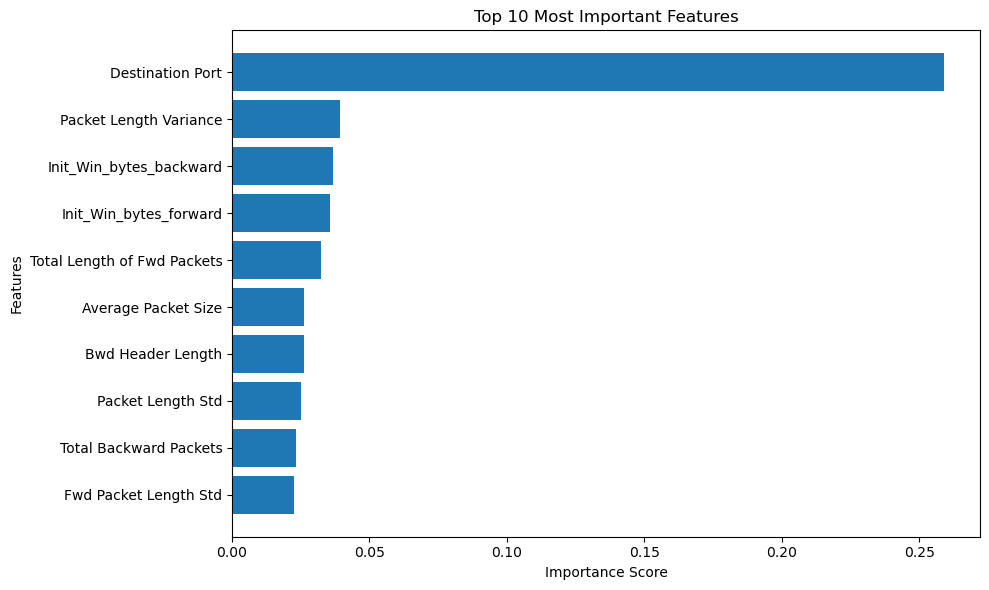

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# Sort features
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Plot top 10 features
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df['Feature'][:10][::-1],
    feature_importance_df['Importance'][:10][::-1]
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

### ROC curve

#### How well the model separates Attack vs Benign

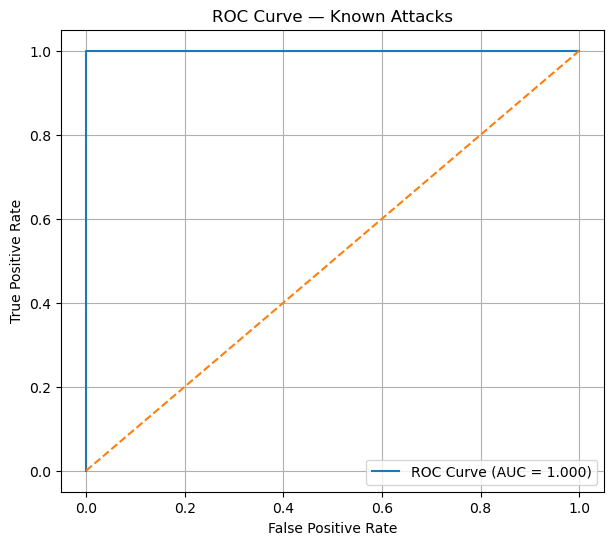

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get prediction probabilities
y_known_proba = rf_model.predict_proba(X_known_test)[:, 1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_known_test, y_known_proba)

roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')

plt.plot([0,1], [0,1], linestyle='--')  # Random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve — Known Attacks")

plt.legend()
plt.grid()

plt.show()

### Precision–Recall Curve

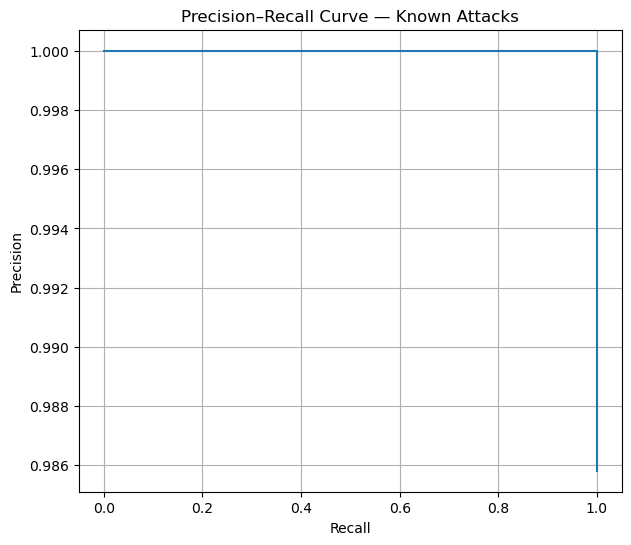

In [23]:
from sklearn.metrics import precision_recall_curve

# Compute Precision-Recall
precision, recall, thresholds = precision_recall_curve(
    y_known_test,
    y_known_proba
)

# Plot Precision-Recall curve
plt.figure(figsize=(7,6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision–Recall Curve — Known Attacks")

plt.grid()

plt.show()

## Unsupervised learning

### Extract and scaling Only Benign Data

In [24]:
# Keep only benign samples for training
X_train_benign = X_train[y_train == "Benign"]

print("Benign training samples:", X_train_benign.shape)


from sklearn.preprocessing import StandardScaler

scaler_unsup = StandardScaler()

X_train_benign_scaled = scaler_unsup.fit_transform(X_train_benign)

# Scale zero-day data
X_zero_unsup_scaled = scaler_unsup.transform(X_zero)

print("Unsupervised scaling complete")

Benign training samples: (961294, 78)
Unsupervised scaling complete


### Isolation Forest and anomaly detection

In [39]:
from sklearn.ensemble import IsolationForest


for contamination in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:

    iso_model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42,
        max_samples="auto",
        max_features=0.8,
        n_jobs=-1
    )

    iso_model.fit(X_train_benign_scaled)

    y_pred = iso_model.predict(X_zero_unsup_scaled)

    y_pred = np.where(
        y_pred == -1,
        "Attack",
        "Benign"
    )

    print(f"\n=== Contamination: {contamination} ===")

    print(
        classification_report(
            y_zero,
            y_pred
        )
    )


=== Contamination: 0.05 ===
              precision    recall  f1-score   support

      Attack       0.01      0.04      0.02      2180
      Benign       0.99      0.95      0.97    168051

    accuracy                           0.94    170231
   macro avg       0.50      0.49      0.49    170231
weighted avg       0.97      0.94      0.96    170231


=== Contamination: 0.1 ===
              precision    recall  f1-score   support

      Attack       0.01      0.04      0.01      2180
      Benign       0.99      0.90      0.94    168051

    accuracy                           0.89    170231
   macro avg       0.50      0.47      0.47    170231
weighted avg       0.97      0.89      0.93    170231


=== Contamination: 0.2 ===
              precision    recall  f1-score   support

      Attack       0.00      0.05      0.01      2180
      Benign       0.98      0.80      0.88    168051

    accuracy                           0.79    170231
   macro avg       0.49      0.42      0.44

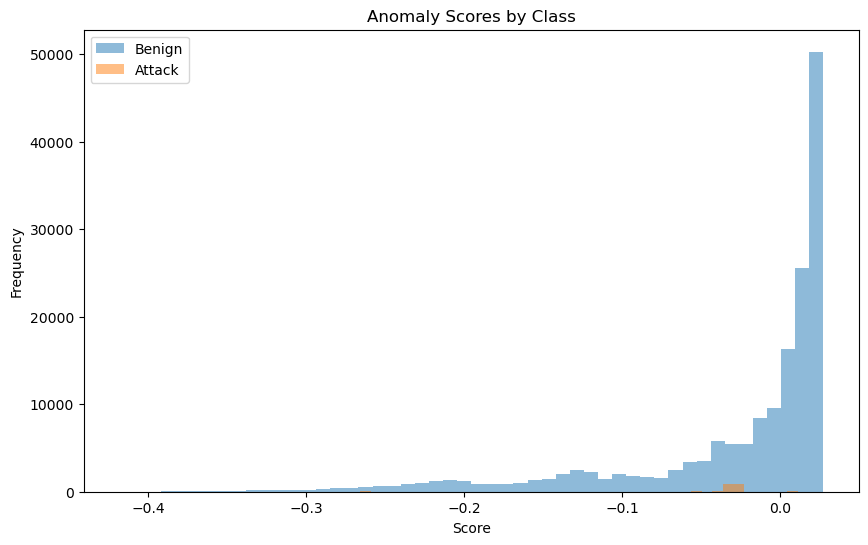

In [41]:
import matplotlib.pyplot as plt

scores = iso_model.decision_function(
    X_zero_unsup_scaled
)

plt.figure(figsize=(10,6))

plt.hist(
    scores[y_zero == "Benign"],
    bins=50,
    alpha=0.5,
    label="Benign"
)

plt.hist(
    scores[y_zero == "Attack"],
    bins=50,
    alpha=0.5,
    label="Attack"
)

plt.title("Anomaly Scores by Class")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()

plt.show()

### Confusion Matrix

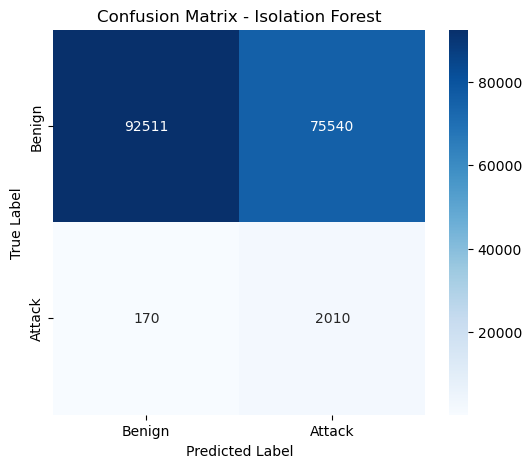

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(
    y_zero,
    y_zero_unsup_pred,
    labels=["Benign", "Attack"]
)

# Plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Attack"],
    yticklabels=["Benign", "Attack"]
)

plt.title("Confusion Matrix - Isolation Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

ROC-AUC score

In [43]:
from sklearn.metrics import roc_auc_score

scores = iso_model.decision_function(
    X_zero_unsup_scaled
)

auc = roc_auc_score(
    y_zero_encoded,
    -scores
)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.30384204440122176


### ROC Curve Plot

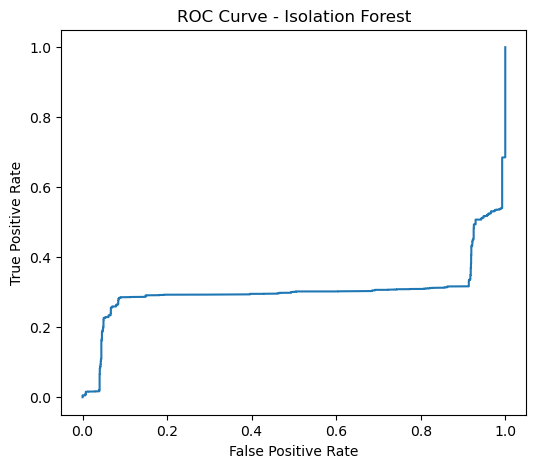

In [44]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_zero_encoded,
    -scores
)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.title("ROC Curve - Isolation Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

# Conclusion

...